# Student Scores Analysis

Analyzes the `StudentScores` sheet from `practice_dataset.xlsx`: computes totals, averages, pass/fail status, and per-subject rankings.

**Data source**: `data/practice_dataset.xlsx` (sheet: `StudentScores`)

**Expected columns**: `Name`, `Math`, `Science`, `English`

> Adjust `SUBJECTS` and `NAME_COL` below if the actual column names differ.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

SUBJECTS = ['Math', 'Science', 'English']
NAME_COL = 'Name'
PASS_THRESHOLD = 40

## Load Data

In [5]:
DATA_PATH = 'data/practice_dataset.xlsx'

students_df = pd.read_excel(DATA_PATH, sheet_name='StudentScores')
students_df.head()

,Name,Math,Science,English
0,Alice,75,71,94
1,Bob,85,63,75
2,Charlie,50,75,63
3,David,57,77,56
4,Eva,98,72,52


## Total and Average Scores per Student

In [6]:
students_df['TotalScore'] = students_df[SUBJECTS].sum(axis=1)
students_df['AverageScore'] = students_df[SUBJECTS].mean(axis=1)
students_df.head()

,Name,Math,Science,English,TotalScore,AverageScore
0,Alice,75,71,94,240,80.000000
1,Bob,85,63,75,223,74.333333
2,Charlie,50,75,63,188,62.666667
3,David,57,77,56,190,63.333333
4,Eva,98,72,52,222,74.000000


## Top 5 Students by Average Score

In [7]:
top_5_students = students_df.sort_values(by='AverageScore', ascending=False).head(5)
top_5_students

,Name,Math,Science,English,TotalScore,AverageScore
5,Frank,84,63,96,243,81.000000
7,Helen,96,51,95,242,80.666667
0,Alice,75,71,94,240,80.000000
1,Bob,85,63,75,223,74.333333
4,Eva,98,72,52,222,74.000000


## Pass / Fail Status

A student passes if every subject score is at or above `PASS_THRESHOLD`.

In [8]:
students_df['Status'] = students_df[SUBJECTS].apply(
    lambda row: 'Pass' if (row >= PASS_THRESHOLD).all() else 'Fail', axis=1
)
students_df[[NAME_COL, 'TotalScore', 'AverageScore', 'Status']].head()

,Name,TotalScore,AverageScore,Status
0,Alice,240,80.000000,Pass
1,Bob,223,74.333333,Pass
2,Charlie,188,62.666667,Pass
3,David,190,63.333333,Pass
4,Eva,222,74.000000,Pass


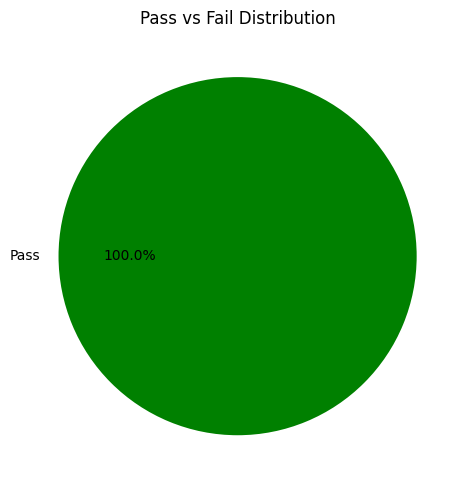

In [9]:
status_counts = students_df['Status'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
        colors=['green', 'red'])
plt.title('Pass vs Fail Distribution')
plt.tight_layout()
plt.show()

## Subject-wise Average Score

In [10]:
subject_avg = students_df[SUBJECTS].mean()
subject_avg

Math       76.125
Science    68.125
English    75.375
dtype: float64

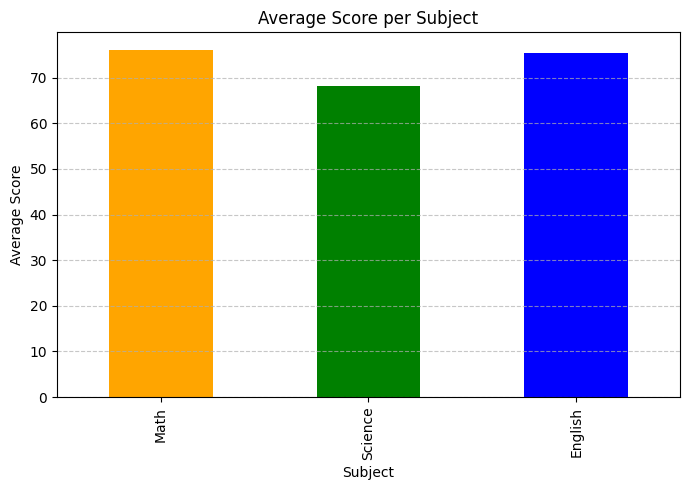

In [11]:
plt.figure(figsize=(7, 5))
subject_avg.plot(kind='bar', color=['orange', 'green', 'blue'])
plt.title('Average Score per Subject')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Top Student per Subject

In [12]:
top_per_subject = {
    subject: students_df.loc[students_df[subject].idxmax(), NAME_COL]
    for subject in SUBJECTS
}
top_per_subject

{'Math': 'Eva', 'Science': 'David', 'English': 'Frank'}

## Score Comparison for Top 5 Students (Grouped Bar Chart)

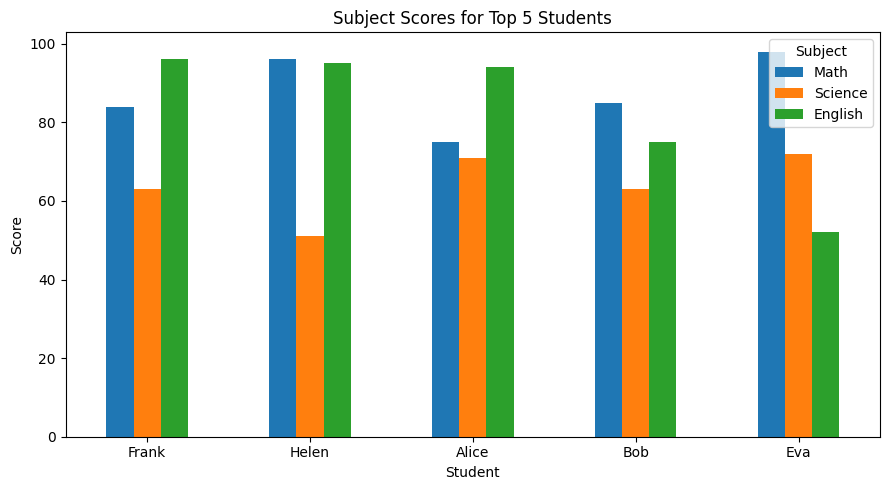

In [13]:
top5 = top_5_students.set_index(NAME_COL)[SUBJECTS]

top5.plot(kind='bar', figsize=(9, 5))
plt.title('Subject Scores for Top 5 Students')
plt.xlabel('Student')
plt.ylabel('Score')
plt.legend(title='Subject')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()